# 沐曦GPU运行nnInteractive说明文档

[nnInteractive](https://github.com/MIC-DKFZ/nnInteractive)是三维交互式分割模型，支持点、涂抹、边界框以及套索等多种提示方式。该模型在涵盖 `CT`、`MRI`、`PET` 和三维显微镜等多样化的数据集上完成训练，并被集成至 `Napari`、`MITK` 等主流图像查看器中。


## 1. 安装
### 1.1 环境准备
使用沐曦开发者社区提供的[maca-pytorch镜像](https://developer.metax-tech.com/softnova/docker?chip_name=%E6%9B%A6%E4%BA%91C500%E7%B3%BB%E5%88%97&package_name=maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64)启动容器：

```bash
docker run -it --name test-nninteractive --device=/dev/mxcd --device=/dev/dri --group-add video --shm-size=8G --security-opt seccomp=unconfined --ulimit memlock=-1  --ulimit stack=67108864 -v /workspace:/workspace cr.metax-tech.com/public-library/maca-pytorch:3.8.0.11-torch2.6-py310-ubuntu24.04-amd64 /bin/bash
```
**参数说明：**
- `--device=/dev/mxcd --device=/dev/dri`：挂载沐曦GPU设备
- `--group-add video`：添加video组以访问GPU
- `--shm-size=8G`：设置共享内存大小
- `-v`：挂载工作目录

> 如需使用更新版本，请访问[沐曦开发者|镜像资源中心](https://developer.metax-tech.com/softnova/docker/)获取对应资源。
### 1.2 安装nnInteractive
安装流程与官方文档保持一致。具体命令如下：


In [ ]:
%%bash
#apt update && apt install git -y
cd /opt
git clone https://github.com/MIC-DKFZ/nnInteractive.git
cd nnInteractive/ 
git rev-parse HEAD
pip install -e ./client
pip install -e . 

### 1.3 环境验证

In [8]:
!pip show nnInteractive
import torch
assert torch.cuda.is_available()
print('PyTorch version:', torch.__version__)
print('CUDA OK:', torch.cuda.get_device_name(0))

Name: nnInteractive
Version: 2.5.1
Summary: Inference code for nnInteractive
Home-page: https://github.com/MIC-DKFZ/nnInteractive
Author: Helmholtz Imaging Applied Computer Vision Lab
Author-email: Fabian Isensee <f.isensee@dkfz-heidelberg.de>
License: Apache License
                                   Version 2.0, January 2004
                                http://www.apache.org/licenses/
        
           TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION
        
           1. Definitions.
        
              "License" shall mean the terms and conditions for use, reproduction,
              and distribution as defined by Sections 1 through 9 of this document.
        
              "Licensor" shall mean the copyright owner or entity authorized by
              the copyright owner that is granting the License.
        
              "Legal Entity" shall mean the union of the acting entity and all
              other entities that control, are controlled by, or are unde

## 2. 沐曦GPU 运行效果展示
下面展示实现 `nnInteractive` 核心功能的精简脚本（改编自原项目[readme.md文档](https://github.com/MIC-DKFZ/nnInteractive/blob/master/readme.md)中相关代码）。只展示`point`和`box`的交互， `lasso` 和 `scribble`方式请参考对应的GUI实现(例如[napari-nninteractive](https://github.com/MIC-DKFZ/napari-nninteractive))。
首次运行会从[Hugging Face](https://huggingface.co/MIC-DKFZ/nnInteractive/)自动下载权重。默认情况下`models.json`被下载至`/root/.nninteractive/models.json`，`nnInteractive_v1.0`被下载至`/root/.nninteractive/models/nnInteractive_v1.0`

In [ ]:
!wget --show-progress -O /tmp/spleen_03.nii.gz https://raw.githubusercontent.com/NVIDIA-Medtech/NV-Segment-CTMR/f9f5f51b589e5dc9c23c453cf5138398e4084056/NV-Segment-CT/example/spleen_03.nii.gz

>为提升 `Conv3D` 在沐曦 GPU 上的性能,请设置环境变量：export PYTORCH_DEFAULT_NDHWC=1

In [ ]:
%env PYTORCH_DEFAULT_NDHWC=1

In [5]:
import os
import torch
import SimpleITK as sitk
import numpy as np

FILENAME='/tmp/spleen_03.nii.gz'
from nnInteractive.model_management import ensure_model_available, get_default_model_id
model_id = get_default_model_id() 
model_path = ensure_model_available(model_id)
from nnInteractive.inference.inference_session import nnInteractiveInferenceSession
session = nnInteractiveInferenceSession(
    device=torch.device("cuda:0"),  # Set inference device
    use_torch_compile=False,  # Compiles the net for faster predictions. The one-time (slow) compile
                              # is paid during initialize_from_trained_model_folder() below (it warms
                              # up automatically), NOT on your first prompt. Worth it for long-lived
                              # processes (the server enables it by default) or longer sessions.
    verbose=False,
    torch_n_threads=os.cpu_count(),  # Use available CPU cores, cap this if your system has a gigantic CPU (64+ cores)
    do_autozoom=True,  # Enables AutoZoom for better patching
)
session.initialize_from_trained_model_folder(str(model_path))

input_image = sitk.ReadImage(FILENAME)
img_sitk  = sitk.GetArrayFromImage(input_image)  # Ensure shape (1, x, y, z)
img_transposed = np.transpose(img_sitk, (2, 1, 0))
img = img_transposed[None, ...]

if img.ndim != 4:
    raise ValueError("Input image must be 4D with shape (1, x, y, z)")

session.set_image(img)

target_tensor = torch.zeros(img.shape[1:], dtype=torch.uint8)  # Must be 3D (x, y, z)
session.set_target_buffer(target_tensor)

session initialized
Model license:
CC BY-NC-SA 4.0


warmup forward pass complete in 0.2s; the first prediction will be fast


In [6]:
# Example: Add a **positive** point interaction
# POINT_COORDINATES should be a tuple (x, y, z) specifying the point location.
POINT_COORDINATES0=(113,204,20)
changed_bbox = session.add_point_interaction(POINT_COORDINATES0, include_interaction=True)


# Example: Add a **negative** point interaction
# To make any interaction negative set include_interaction=False
POINT_COORDINATES1=(141,184,20)
session.add_point_interaction(POINT_COORDINATES1, include_interaction=False)

Initialize interactions with dense torch.Tensor (auto)
Added new point interaction: center [113, 204, 20], zoom-out factor 1
Took 0.286 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 0.314s
Added new point interaction: center [141, 184, 20], zoom-out factor 1
Took 0.257 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 0.286s


[[45, 237], [88, 280], [0, 40]]

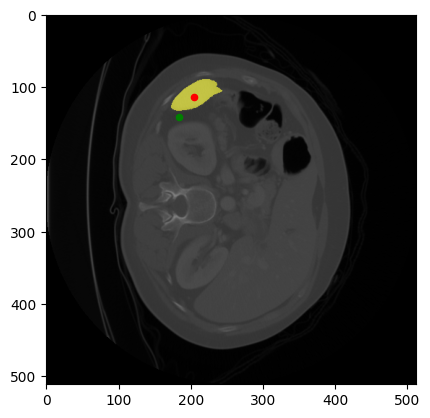

In [7]:
#%% visualize results
import matplotlib.pyplot as plt
%matplotlib inline
slice_id=20

img_np = img[0,:,:,slice_id]
mask_np = target_tensor[:,:,slice_id].detach().cpu().numpy()

img_np=(img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
rgb_img = np.stack([img_np]*3, axis=-1)
overlay = np.zeros_like(rgb_img)
overlay[mask_np==1] = [1.0, 1.0, 0.0]   
plt.imshow(rgb_img)
plt.imshow(overlay, alpha=0.5) 
pts_x, pts_y = POINT_COORDINATES0[1],POINT_COORDINATES0[0]
plt.scatter(pts_x, pts_y, s=20, c='red', marker='o',zorder=10)
pts_x, pts_y = POINT_COORDINATES1[1],POINT_COORDINATES1[0]
plt.scatter(pts_x, pts_y, s=20, c='green', marker='o',zorder=10)
plt.show()


In [8]:
# Example: Add a bounding box interaction
# BBOX_COORDINATES must be specified as [[x1, x2], [y1, y2], [z1, z2]] (half-open intervals).
# Note: nnInteractive pre-trained models currently only support **2D bounding boxes**.
# This means that **one dimension must be [d, d+1]** to indicate a single slice.

# Example of a 2D bounding box in the axial plane (XY slice at depth Z)
# BBOX_COORDINATES = [[30, 80], [40, 100], [10, 11]]  # X: 30-80, Y: 40-100, Z: slice 10
BBOX_COORDINATES = [[295, 423], [205, 379], [10, 11]]
session.add_bbox_interaction(BBOX_COORDINATES, include_interaction=True)

Added new bbox interaction: center [359, 292, 10], zoom-out factor 1.2395833333333333
Took 0.302 s for initial prediction at zoom out factor 1.2395833333333333
AutoZoom zoom out factor 1.2395833333333333
AutoZoom zoom out factor 1.859375
Zoom out took 0.803 s, max zoom out factor 2.7890625
Took 2.331 s for refining the segmentation with 9 bounding boxes
Done. Total time 3.52s


[[15, 512], [105, 450], [0, 40]]

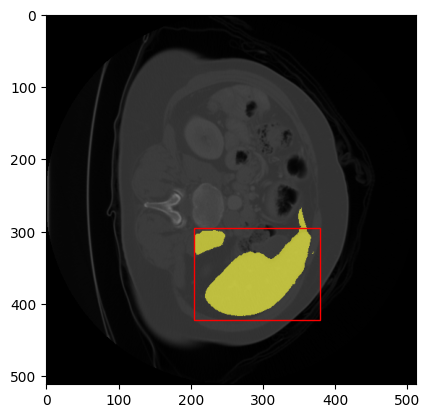

In [9]:
#%% visualize results
import matplotlib.patches as patches
slice_id=10

img_np = img[0,:,:,slice_id]
mask_np = target_tensor[:,:,slice_id].detach().cpu().numpy()

img_np=(img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)
rgb_img = np.stack([img_np]*3, axis=-1)
overlay = np.zeros_like(rgb_img)
overlay[mask_np==1] = [1.0, 1.0, 0.0]   
plt.imshow(rgb_img)
plt.imshow(overlay, alpha=0.5) 
rect = patches.Rectangle(
    (BBOX_COORDINATES[1][0], BBOX_COORDINATES[0][0]), BBOX_COORDINATES[1][1]-BBOX_COORDINATES[1][0], BBOX_COORDINATES[0][1]-BBOX_COORDINATES[0][0],
    linewidth=1, edgecolor='red', facecolor='none'
)


ax = plt.gca()
ax.add_patch(rect)

plt.show()

In [10]:
# You can combine any number of interactions as needed. 
# The model refines the segmentation result incrementally with each new interaction.

# --- Retrieve Results ---
# The result already lives in your target buffer: target_tensor IS session.target_buffer (the
# same object, written in place). So just read it — no copy needed to inspect it or save it:
result_np = target_tensor.cpu().numpy()
# sitk.WriteImage(sitk.GetImageFromArray(result_np), "segmentation.nii.gz")

# You only need a COPY if you want to keep this result in memory while you reuse the buffer for
# the next object, because reset_interactions() / reusing the buffer overwrites it in place:
# saved = target_tensor.clone()        # torch  (numpy buffer: target_tensor.copy())

# --- Start a New Object Segmentation ---
session.reset_interactions()  # Clears the target buffer and resets interactions
# (Alternatively, give each object its own fresh buffer instead of resetting:)
# session.set_target_buffer(torch.zeros(img.shape[1:], dtype=torch.uint8))

# Now you can start segmenting the next object in the image.

# --- Set a New Image ---
# Setting a new image also requires setting a new matching target buffer


---
本文档仅提供相关软件的配置与使用说明，不包含亦不分发前述软件的源代码或目标代码，且不涉及对其源代码的任何修改。您按照本文档配置、部署或使用相关软件时，应遵守适用许可证规定的条款及条件。相关软件的源代码、许可证全文、版权与归属声明及其他项目文档，请以其官方网站或原始发布页面为准。

### Copyright (c) 2026 MetaX Integrated Circuits (Shanghai) Co., Ltd. All rights reserved.